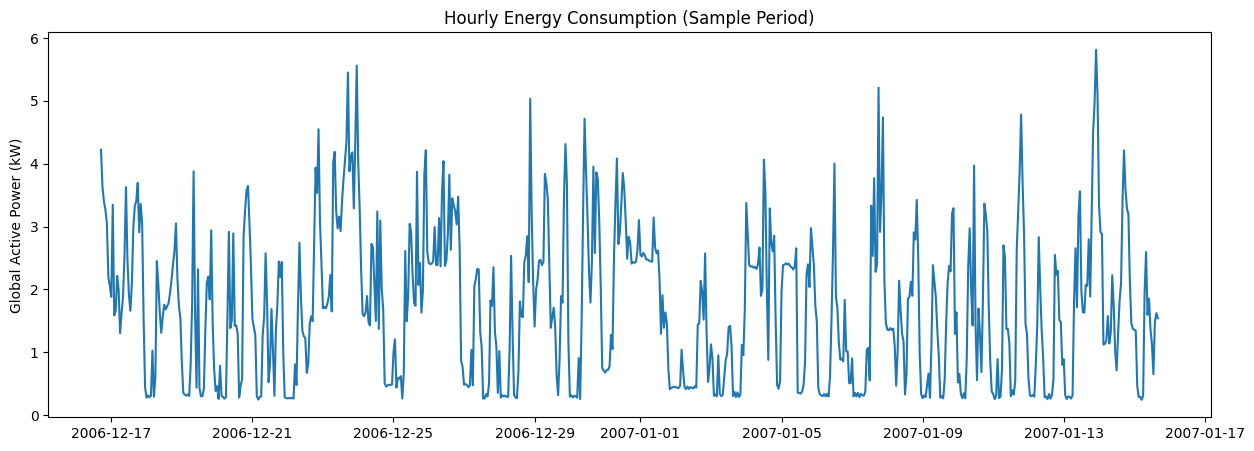

ADF Statistic: (np.float64(-11.446540030570816), np.float64(5.999412177904017e-21), 44, 17432, {'1%': np.float64(-3.43072518719614), '5%': np.float64(-2.8617058182089496), '10%': np.float64(-2.566858260735454)}, np.float64(32924.60872512807))
p-value: (np.float64(-11.446540030570816), np.float64(5.999412177904017e-21), 44, 17432, {'1%': np.float64(-3.43072518719614), '5%': np.float64(-2.8617058182089496), '10%': np.float64(-2.566858260735454)}, np.float64(32924.60872512807))
Training ARIMA...

ARIMA Results - MAE: 0.3282, RMSE: 0.5137


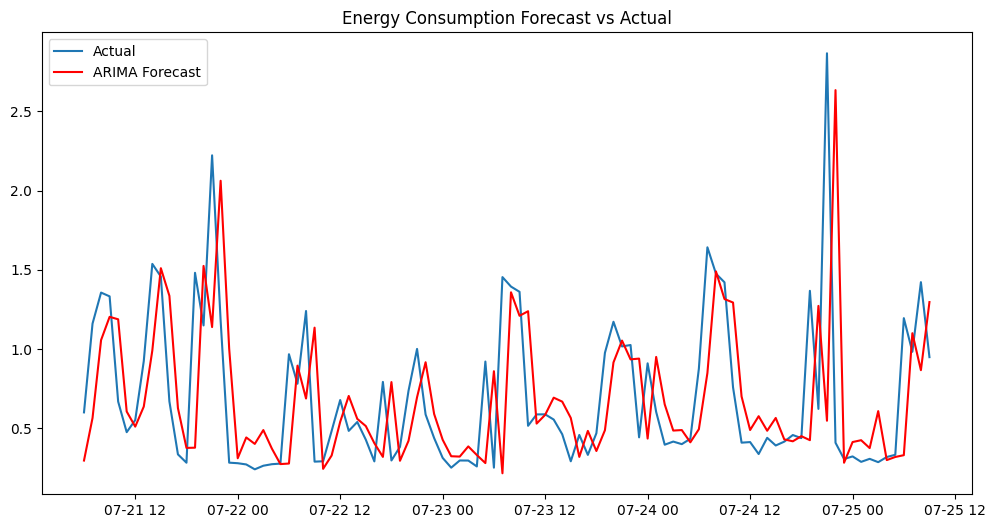

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
# import xgboost as xgb  # Uncomment after installing
# from prophet import Prophet # Uncomment after installing

# 1. LOAD AND PREPROCESS DATA
df = pd.read_csv('household_power_consumption.csv', low_memory=False)

# Handle '?' values and convert to numeric
for col in df.columns[2:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Combine Date and Time into a single index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Fill missing values (forward fill is standard for time series)
df = df.ffill()

# Resample to Hourly to reduce noise and speed up training
df_hourly = df['Global_active_power'].resample('h').mean().to_frame()

# 2. EXPLORATORY DATA ANALYSIS (EDA)
plt.figure(figsize=(15, 5))
plt.plot(df_hourly.iloc[:720]) # Plotting 1 month (720 hours)
plt.title('Hourly Energy Consumption (Sample Period)')
plt.ylabel('Global Active Power (kW)')
plt.show()

# 3. STATIONARITY TEST (ADF TEST)
result = adfuller(df_hourly['Global_active_power'].dropna())
print(f'ADF Statistic: {result}')
print(f'p-value: {result}') # If p < 0.05, data is stationary

# 4. MODELING - SPLIT DATA
train_size = int(len(df_hourly) * 0.8)
train, test = df_hourly.iloc[:train_size], df_hourly.iloc[train_size:]

# --- APPROACH A: ARIMA ---
print("Training ARIMA...")
history = [x for x in train['Global_active_power']]
predictions_arima = []
# For brevity in the task, we forecast the first 100 hours of the test set
for t in range(100):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    yhat = model_fit.forecast()
    predictions_arima.append(yhat)
    history.append(test['Global_active_power'].iloc[t])

# --- APPROACH B: PROPHET (Prepare data format) ---
# df_p = df_hourly.reset_index().rename(columns={'Datetime':'ds', 'Global_active_power':'y'})
# model_p = Prophet()
# model_p.fit(df_p.iloc[:train_size])
# forecast = model_p.predict(df_p.iloc[train_size:])

# 5. EVALUATION
mae = mean_absolute_error(test['Global_active_power'].iloc[:100], predictions_arima)
rmse = np.sqrt(mean_squared_error(test['Global_active_power'].iloc[:100], predictions_arima))

print(f"\nARIMA Results - MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# 6. VISUALIZATION OF RESULTS
plt.figure(figsize=(12, 6))
plt.plot(test.index[:100], test['Global_active_power'].iloc[:100], label='Actual')
plt.plot(test.index[:100], predictions_arima, label='ARIMA Forecast', color='red')
plt.title('Energy Consumption Forecast vs Actual')
plt.legend()
plt.show()